# 실습 내용

- 데이터 : income_happy.csv
- 단순 선형회귀 모델을 만들고 평가한다.
- 특히 회귀 계수를 명확히 이해한다.
- 예측 결과를 시각화한다.

# 1.환경 준비

In [1]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

In [2]:
# 데이터 읽어오기
path = 'data/income_happy.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [3]:
# 상위 몇 개 행 확인
df.head()

,income,happiness
0,3.862647,2.314489
1,4.979381,3.433490
2,4.923957,4.599373
3,3.214372,2.791114
4,7.196409,5.596398


**데이터 설명**

- income: 수입 (단위: 10,000$)
- happiness: 행복 정도 (1~ 10)

In [4]:
# 하위 몇 개 행 확인
df.tail()

,income,happiness
493,5.249209,4.568705
494,3.471799,2.535002
495,6.087610,4.397451
496,3.440847,2.070664
497,4.530545,3.710193


In [5]:
# 기술통계 확인
df.describe()

,income,happiness
count,498.000000,498.000000
mean,4.466902,3.392859
std,1.737527,1.432813
min,1.506275,0.266044
25%,3.006256,2.265864
50%,4.423710,3.472536
75%,5.991913,4.502621
max,7.481521,6.863388


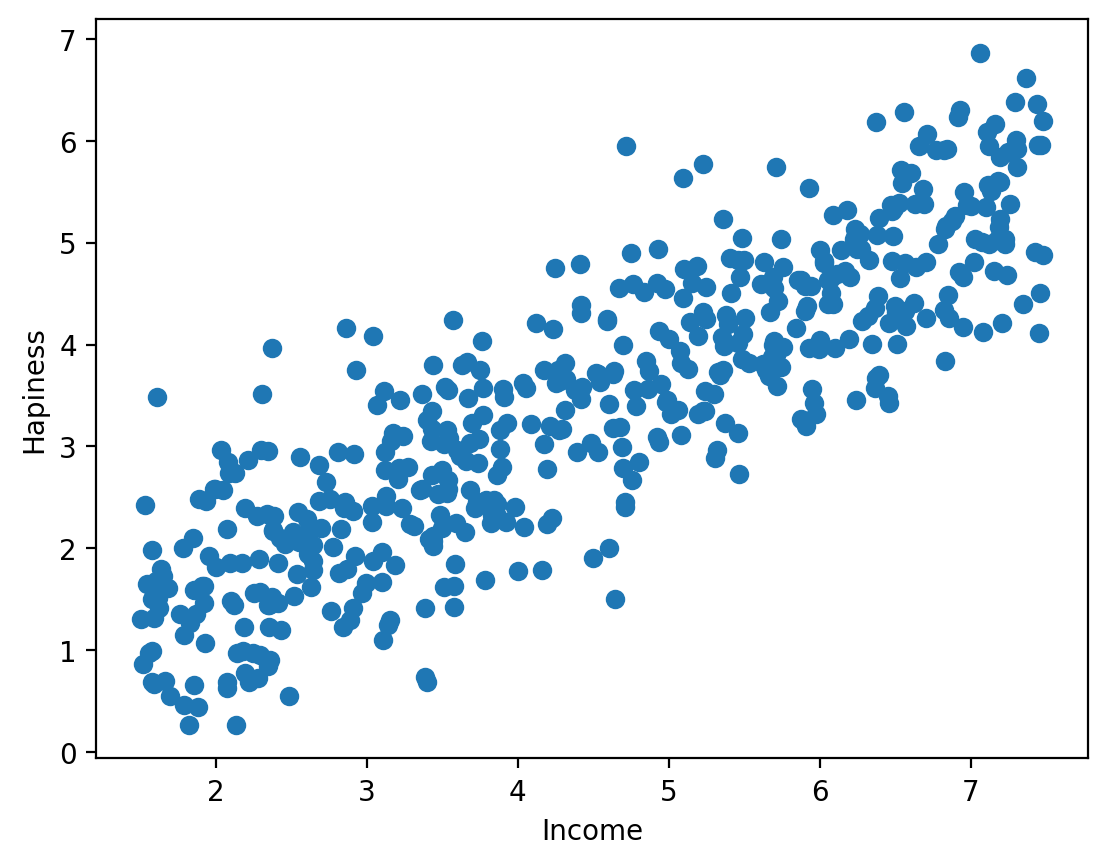

In [6]:
# Income --> Hapiness 관계
plt.scatter(x='income', y='happiness', data=df)
plt.xlabel('Income')
plt.ylabel('Hapiness')
plt.show()

# 3.데이터 준비

**1) x, y 분리**

In [7]:
# target 확인
target = 'happiness'

# 데이터 분리
X = df.drop(target, axis=1)
y = df.loc[:, target]

**2) 학습용, 평가용 데이터 분리**
- random_state=1

In [8]:
# 모듈 불러오기
from sklearn.model_selection import train_test_split

# 7:3으로 분리
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=1)

# 4.모델링

In [9]:
# 1단계: 불러오기
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [10]:
# 2단계: 선언하기
model = LinearRegression()

In [11]:
# 3단계: 학습하기
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
# 4단계: 예측하기
y_pred = model.predict(X_test)

In [13]:
# 5단계: 평가하기
from sklearn.metrics import r2_score, mean_absolute_error

print('MAE:',mean_absolute_error(y_test, y_pred))   # 평균절대오차
print('R2:',r2_score(y_test, y_pred))               # r2

MAE: 0.5588237111283767
R2: 0.7545536758581621


In [14]:
# 회귀계수 확인
print(model.coef_)
print(model.intercept_)

[0.72244152]
0.1584944116952034


$$ \large happiness = 0.72 \times Income + 0.16 $$

# 5.기타


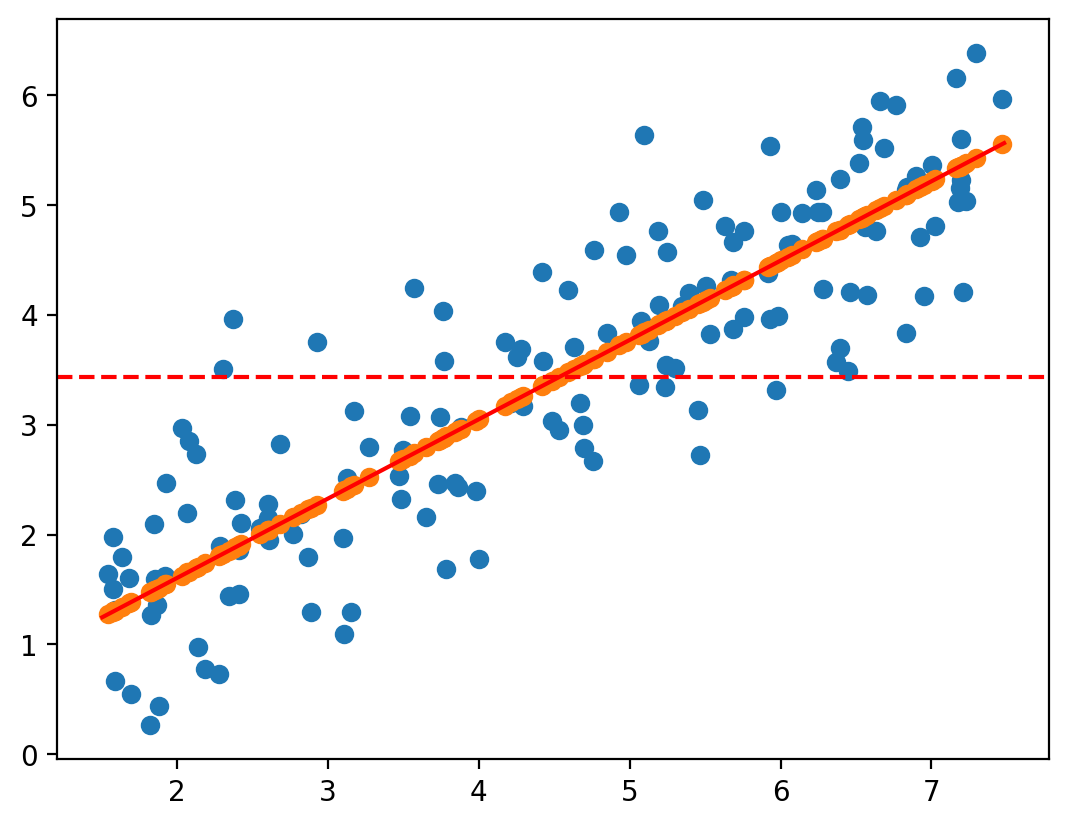

In [15]:
# 예측값, 실제값 시각화

plt.scatter(X_test, y_test) # 실제값 산점도
plt.scatter(X_test, y_pred) # 예측값 산점도

plt.axhline(y_test.mean(), color='r', linestyle='--')

# 회귀선 y=ax+b
a = model.coef_   #가중치
b = model.intercept_ #편향
x = np.array([X_train.min(), X_train.max()]) # 배열형태로 처음과 끝을 결정
reg = a * x + b
plt.plot(x,reg, color='r')

#확인
plt.show()